# Notebook 05 — Mapping and Spatiotemporal Analysis

This notebook visualizes drought patterns across Afghanistan and validates the CDI against known drought events.

| Analysis | Purpose |
|----------|---------|
| Current Conditions Map | Latest CDI snapshot by district |
| Time Series Validation | Compare CDI to known drought periods |
| Hotspot Mapping | Identify persistently drought-prone districts |
| Seasonality Analysis | Provincial drought patterns by month |
| Variability Analysis | Districts with most volatile conditions |
| Anomaly Comparison | Current year vs. historical baseline |

Validation approach: Visual comparison with SPEI Global Drought Monitor and alignment with documented drought events.

In [94]:
# Imports and project paths
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import numpy as np
import seaborn as sns
import geopandas as gpd

PROJECT_ROOT = Path.cwd().parent
data_dir = PROJECT_ROOT / "data" / "processed"

In [95]:
# Load the datasets
df = pd.read_csv(data_dir / "afg_drought_indicators_2000_2025.csv")
df2 = pd.read_csv(data_dir / "afg_district_drought_summary.csv")
districts_gdf = gpd.read_file(PROJECT_ROOT / "data" / "raw" / "afg_district_lookup.geojson")

print(f"\nDataset shape: {df.shape}")
print(f"\nColumns available:")
print(df.columns.tolist())

print(f"\nDataset shape: {df2.shape}")
print(f"\nColumns available:")
print(df2.columns.tolist())


Dataset shape: (122493, 21)

Columns available:
['ADM2_CODE', 'ADM2_NAME', 'ADM1_NAME', 'date', 'year', 'month', 'VCI', 'TCI', 'SPI', 'VCI_clipped', 'TCI_clipped', 'SPI_norm', 'SPI_norm_clipped', 'CDI', 'CDI_alt', 'CDI_partial', 'NDVI_was_filled', 'LST_was_filled', 'VCI_out_of_range', 'TCI_out_of_range', 'any_quality_flag']

Dataset shape: (399, 12)

Columns available:
['ADM2_CODE', 'ADM2_NAME', 'ADM1_NAME', 'CDI_mean', 'CDI_std', 'CDI_min', 'CDI_max', 'CDI_median', 'n_observations', 'n_partial', 'worst_drought_date', 'worst_drought_month']


---
## Current Drought Conditions Map

Choropleth map showing the most recent CDI values at the district level.

For Reference:

| CDI Range | Interpretation | 
|-----------|----------------|
| **0–10** | Extreme drought |
| **10–20** | Severe drought |
| **20–30** | Moderate drought |
| **30–40** | Mild drought |
| **40–50** | Near normal (dry) |
| **50** | Normal conditions | 
| **50–100** | Wet |

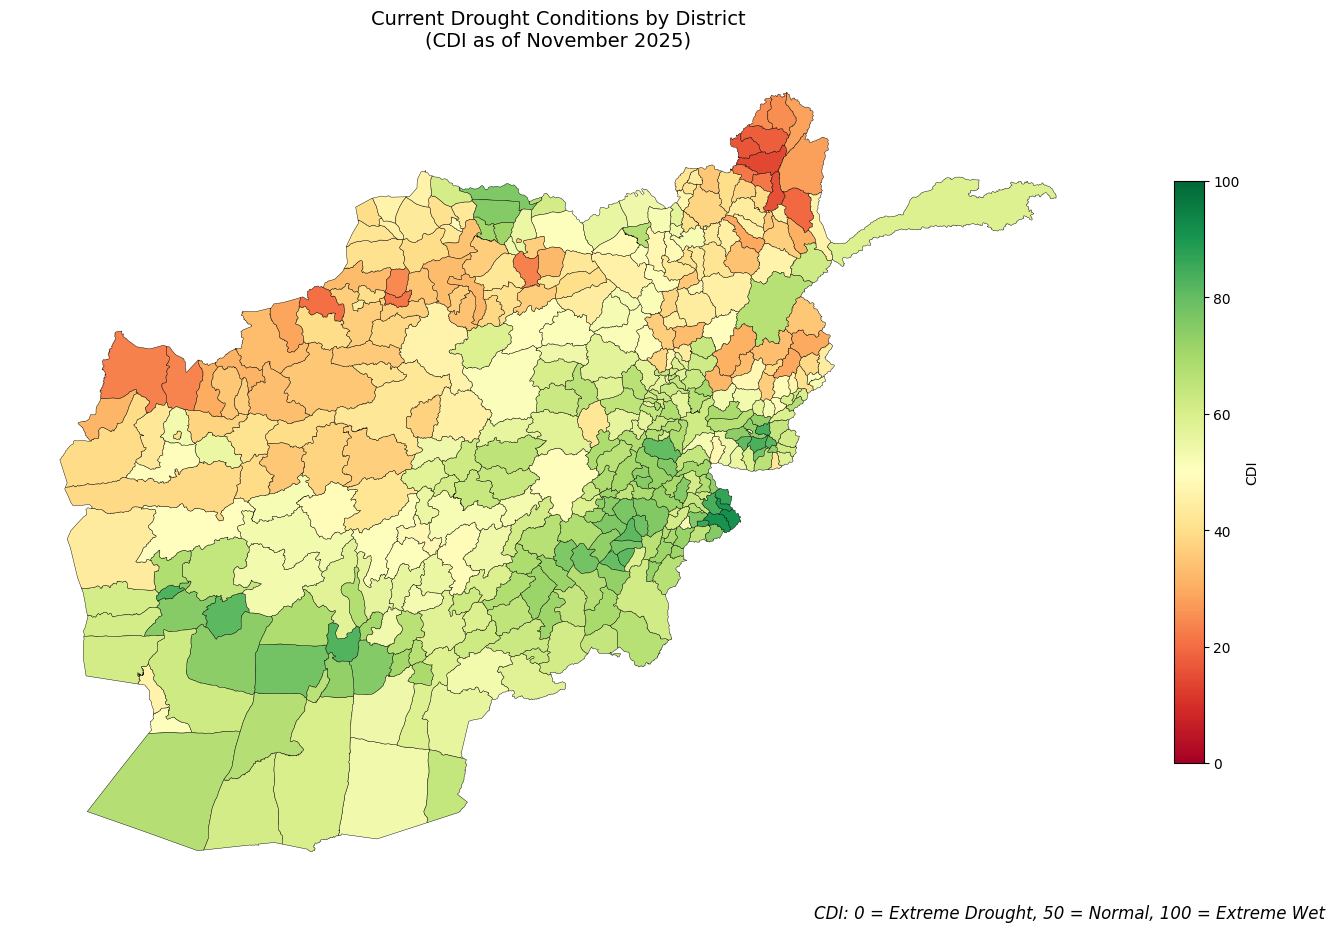

In [96]:
# CDI Choropleth Map: Current Drought Conditions

# Get the most recent date in the dataset
df["date"] = pd.to_datetime(df["date"])
latest_date = df["date"].max()

# Filter to most recent month's data and merge with district boundaries
recent_cdi = df[df["date"] == latest_date][["ADM2_CODE", "ADM2_NAME", "ADM1_NAME", "CDI"]].copy()
cdi_map = districts_gdf.merge(recent_cdi, on="ADM2_CODE", how="left")

# Choropleth map
fig, ax = plt.subplots(figsize=(14, 10))

cdi_map.plot(
    column="CDI",
    cmap="RdYlGn",
    vmin=0,
    vmax=100,
    legend=True,
    legend_kwds={"label": "CDI", "shrink": 0.6},
    edgecolor="black",
    linewidth=0.3,
    missing_kwds={"color": "lightgrey", "label": "No data"},
    ax=ax
)

ax.set_title(f"Current Drought Conditions by District\n(CDI as of {latest_date.strftime('%B %Y')})", fontsize=14)
ax.axis("off")

# Add a note in bottom right
fig.text(0.95, 0.05, "CDI: 0 = Extreme Drought, 50 = Normal, 100 = Extreme Wet", 
         fontsize=12, ha='right', va='bottom', style='italic', color='black')

plt.tight_layout()
plt.show()

## Validation: Time Series Visualization

Validate that the CDI captures known Afghanistan drought events (2000–2002, 2008, 2018, 2021–2022) by plotting VCI, TCI, SPI, and CDI time series. CDI should show notable dips during these periods at both district and national levels.

In [97]:
# Define known drought periods for shading
drought_periods = [
    ("2000-01-01", "2002-12-31", "2000-2002 Drought"),
    ("2008-01-01", "2008-12-31", "2008 Drought"),
    ("2018-01-01", "2018-12-31", "2018 Drought"),
    ("2021-01-01", "2022-12-31", "2021-2022 Drought"),
]

# Define series to plot (using clipped versions for consistency with CDI computation)
series = [
    ("VCI", "VCI", dict(alpha=0.7, linewidth=1)),
    ("TCI", "TCI", dict(alpha=0.7, linewidth=1)),
    ("SPI_norm", "SPI (normalized)", dict(alpha=0.7, linewidth=1)),
    ("CDI", "CDI", dict(color="black", linewidth=2)),
]

# Plotting functions
def add_drought_shading(ax, show_labels=False):
    for start, end, label in drought_periods:
        ax.axvspan(pd.to_datetime(start), pd.to_datetime(end),
                   alpha=0.2, color="red", label=label if show_labels else "")

def add_reference_lines(ax, lines):
    for y, kw in lines:
        ax.axhline(y=y, **kw)

def plot_series(ax, data, title=None, ylim=None, legend_kw=None, shade_labels=False, ref_lines=None):
    for col, lab, kw in series:
        ax.plot(data["date"], data[col], label=lab, **kw)
    add_drought_shading(ax, show_labels=shade_labels)
    if ref_lines:
        add_reference_lines(ax, ref_lines)
    if title:
        ax.set_title(title)
    if ylim:
        ax.set_ylim(*ylim)
    ax.set_ylabel("Index Value")
    ax.grid(True, alpha=0.3)
    ax.legend(**(legend_kw or {}))


Time Series Validation - Sample Districts:


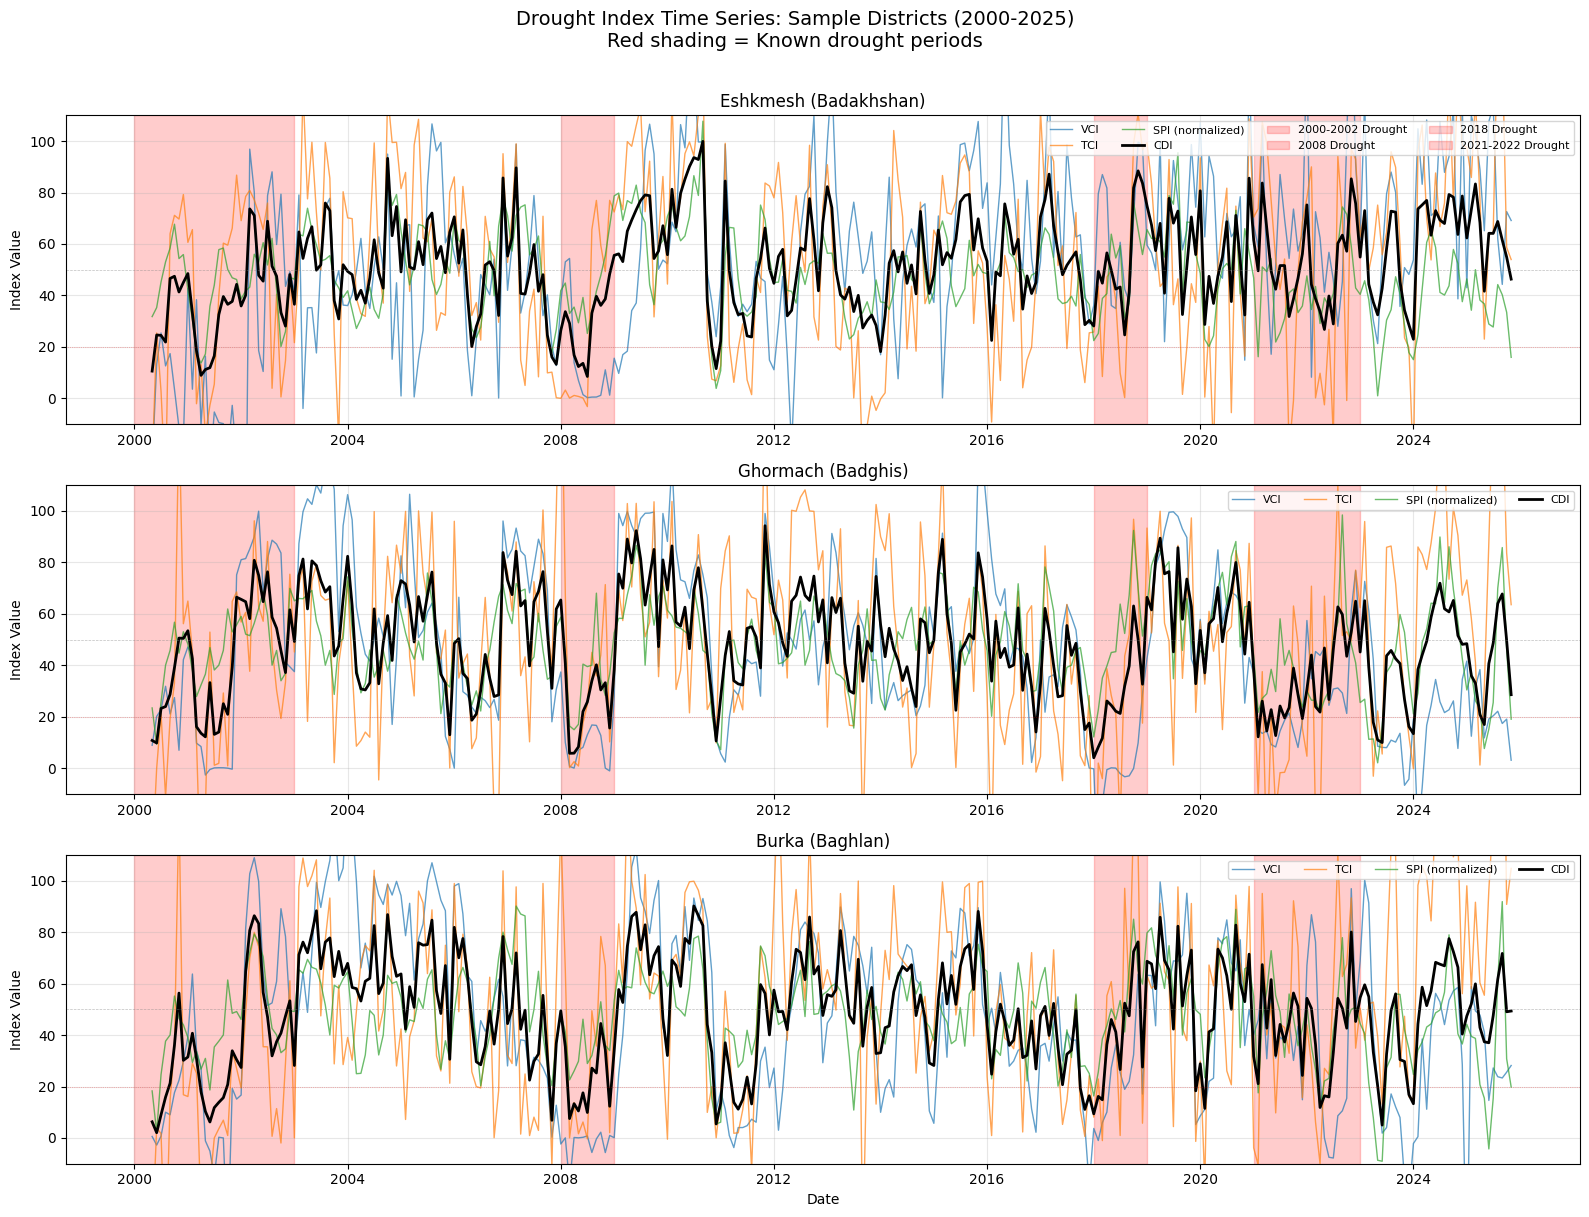

In [98]:
# Sample District Time Series Plots
sample_districts = (
    df.groupby("ADM1_NAME")["ADM2_CODE"].first().head(3).to_numpy()
)

print("Time Series Validation - Sample Districts:")

fig, axes = plt.subplots(len(sample_districts), 1, figsize=(16, 4 * len(sample_districts)))
axes = [axes] if len(sample_districts) == 1 else axes  # handle 1-row case

for i, adm2_code in enumerate(sample_districts):
    d = df.loc[df["ADM2_CODE"].eq(adm2_code)].sort_values("date")
    title = f'{d["ADM2_NAME"].iloc[0]} ({d["ADM1_NAME"].iloc[0]})'

    plot_series(
        axes[i], d, title=title, ylim=(-10, 110),
        legend_kw=dict(loc="upper right", fontsize=8, ncol=4),
        shade_labels=(i == 0),
        ref_lines=[
            (50, dict(color="gray", linestyle="--", alpha=0.5, linewidth=0.5)),
            (20, dict(color="red", linestyle=":", alpha=0.5, linewidth=0.5)),
        ],
    )

axes[-1].set_xlabel("Date")
plt.suptitle(
    "Drought Index Time Series: Sample Districts (2000-2025)\nRed shading = Known drought periods",
    fontsize=14, y=1.01
)
plt.tight_layout()
plt.show()

Time Series Validation - National Average:


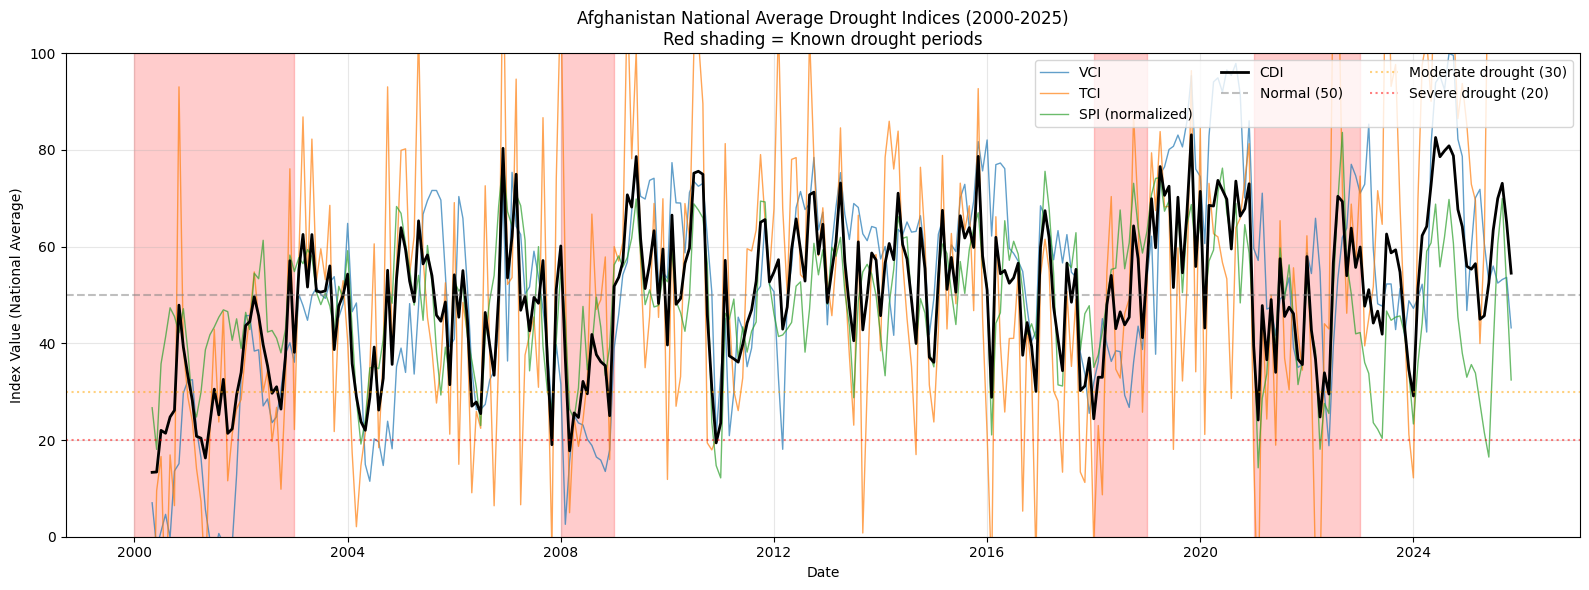

Worst Drought Months (Lowest National CDI):

   date   VCI    TCI  SPI_norm   CDI
2000-05  7.02 -28.05     26.67 13.31
2000-06 -2.30   9.54     18.06 13.39
2001-05  5.61 -10.38     38.66 16.28
2008-03 15.47   4.97     26.43 17.76
2007-11 25.88  -2.67     26.52 19.02
2010-12 20.81  20.25     14.71 19.40
2001-04 16.28   7.30     29.91 20.38
2001-03 22.22  14.11     24.76 20.77
2001-10 -8.82  11.57     46.54 21.37
2000-08  4.63 -16.02     41.28 21.40


In [99]:
# National Average Time Series Plot
print("Time Series Validation - National Average:")

national_avg = (
    df.groupby("date")[["VCI", "TCI", "SPI_norm", "CDI"]]
      .mean()
      .reset_index()
)

fig, ax = plt.subplots(figsize=(16, 6))
plot_series(
    ax, national_avg,
    title="Afghanistan National Average Drought Indices (2000-2025)\nRed shading = Known drought periods",
    ylim=(0, 100),
    legend_kw=dict(loc="upper right", ncol=3),
    ref_lines=[
        (50, dict(color="gray", linestyle="--", alpha=0.5, label="Normal (50)")),
        (30, dict(color="orange", linestyle=":", alpha=0.5, label="Moderate drought (30)")),
        (20, dict(color="red", linestyle=":", alpha=0.5, label="Severe drought (20)")),
    ],
)

ax.set_xlabel("Date")
ax.set_ylabel("Index Value (National Average)")
plt.tight_layout()
plt.show()

# Identify Worst Drought Months (Lowest National CDI)
print("Worst Drought Months (Lowest National CDI):\n")
worst_months = national_avg.nsmallest(10, "CDI")[["date", "VCI", "TCI", "SPI_norm", "CDI"]].round(2)
worst_months["date"] = worst_months["date"].dt.strftime("%Y-%m")
print(worst_months.to_string(index=False))

## Validation: Spatial Maps

Compare CDI maps for selected months against the [SPEI Global Drought Monitor](https://spei.csic.es/map/maps.html) to verify spatial patterns align with established drought indices.

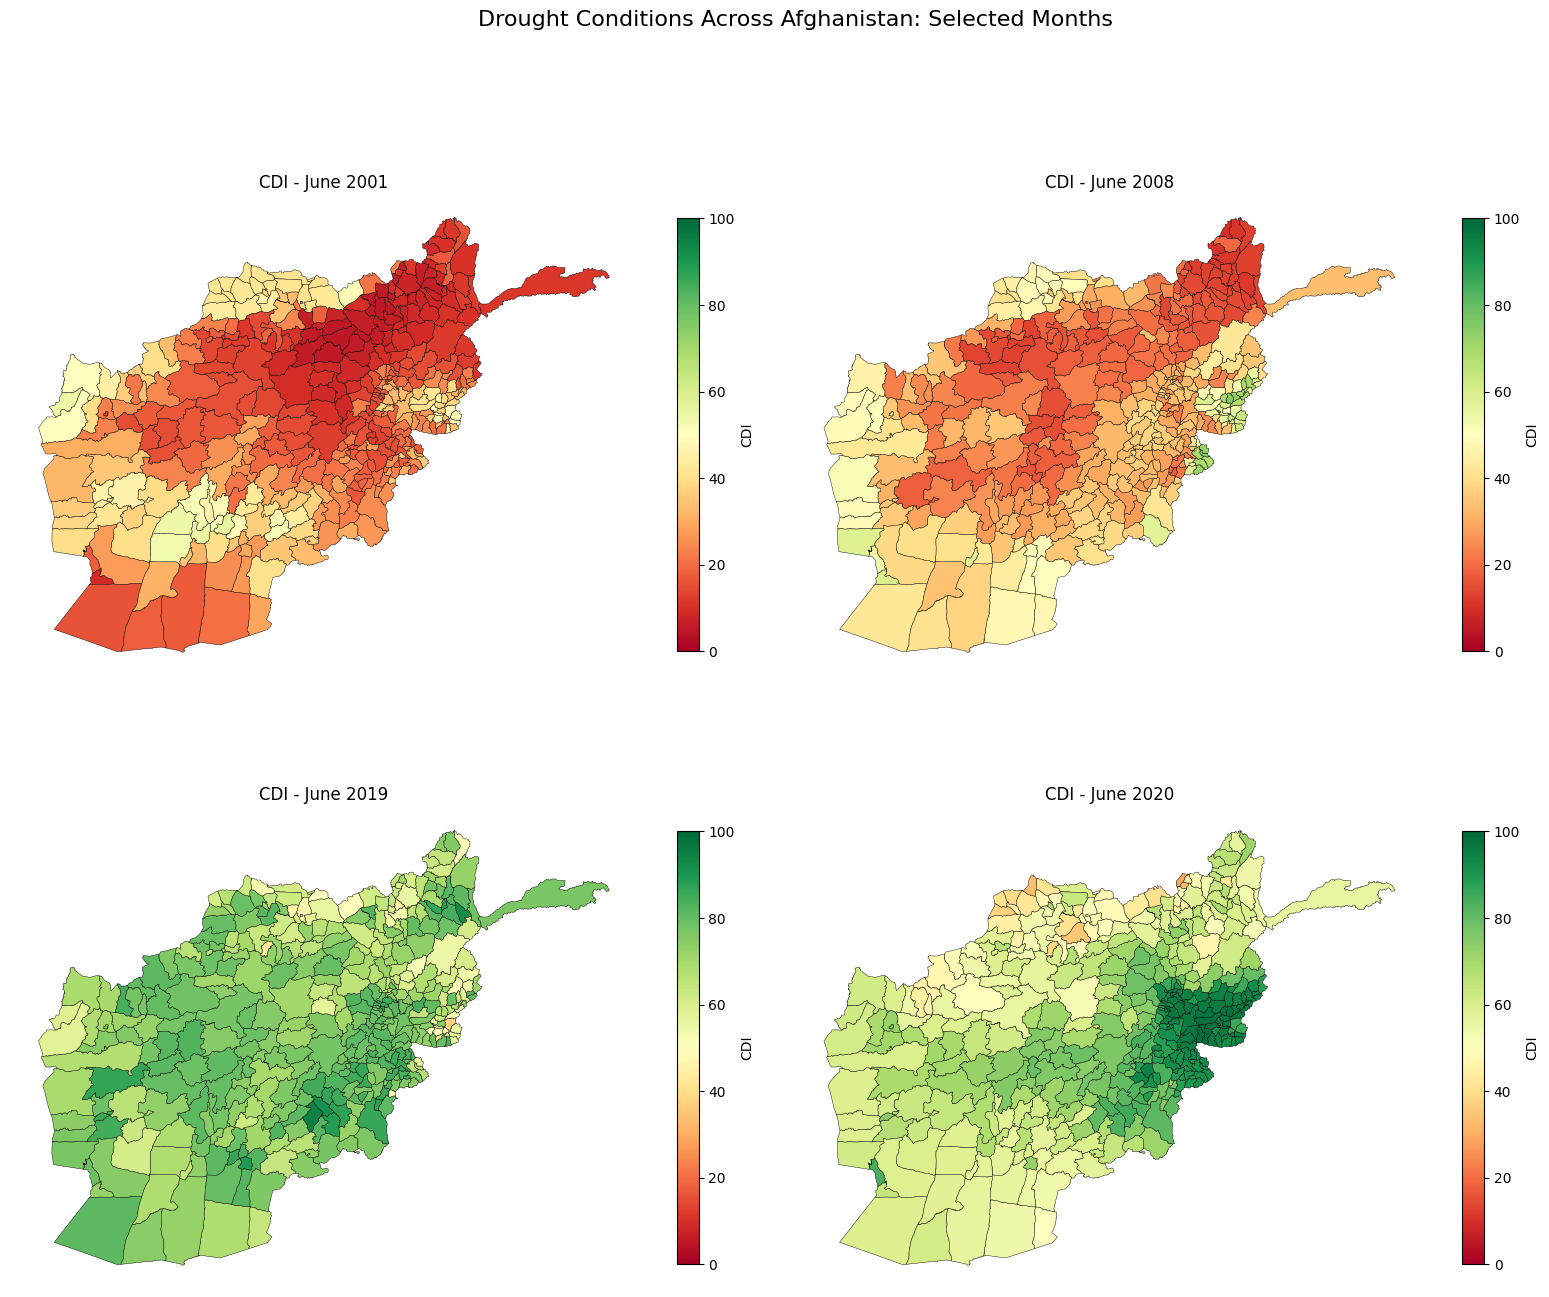

In [100]:
# CDI Maps for Selected Sample Months

selected_dates = ["2001-06-01", "2008-06-01", "2019-06-01", "2020-06-01"]

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for i, date_str in enumerate(selected_dates):
    date = pd.to_datetime(date_str)
    
    # Filter data for this month
    month_cdi = df[df["date"] == date][["ADM2_CODE", "CDI"]].copy()
    month_map = districts_gdf[["ADM2_CODE", "geometry"]].merge(month_cdi, on="ADM2_CODE", how="left")
    
    # Plot
    month_map.plot(
        column="CDI",
        cmap="RdYlGn",
        vmin=0,
        vmax=100,
        legend=True,
        legend_kwds={"label": "CDI", "shrink": 0.6},
        edgecolor="black",
        linewidth=0.3,
        missing_kwds={"color": "lightgrey", "label": "No data"},
        ax=axes[i]
    )
    
    axes[i].set_title(f"CDI - {date.strftime('%B %Y')}", fontsize=12)
    axes[i].axis("off")

plt.suptitle("Drought Conditions Across Afghanistan: Selected Months", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

## Drought Hotspot Persistence

Identify chronically drought-prone districts by mapping the percentage of months spent in drought conditions over the full 25-year period.

| Threshold | Definition | Use Case |
|-----------|------------|----------|
| CDI < 50 | Any drought (below normal) | General drought exposure |
| CDI < 25 | Pronounced drought (moderate–severe) | Priority areas for intervention |

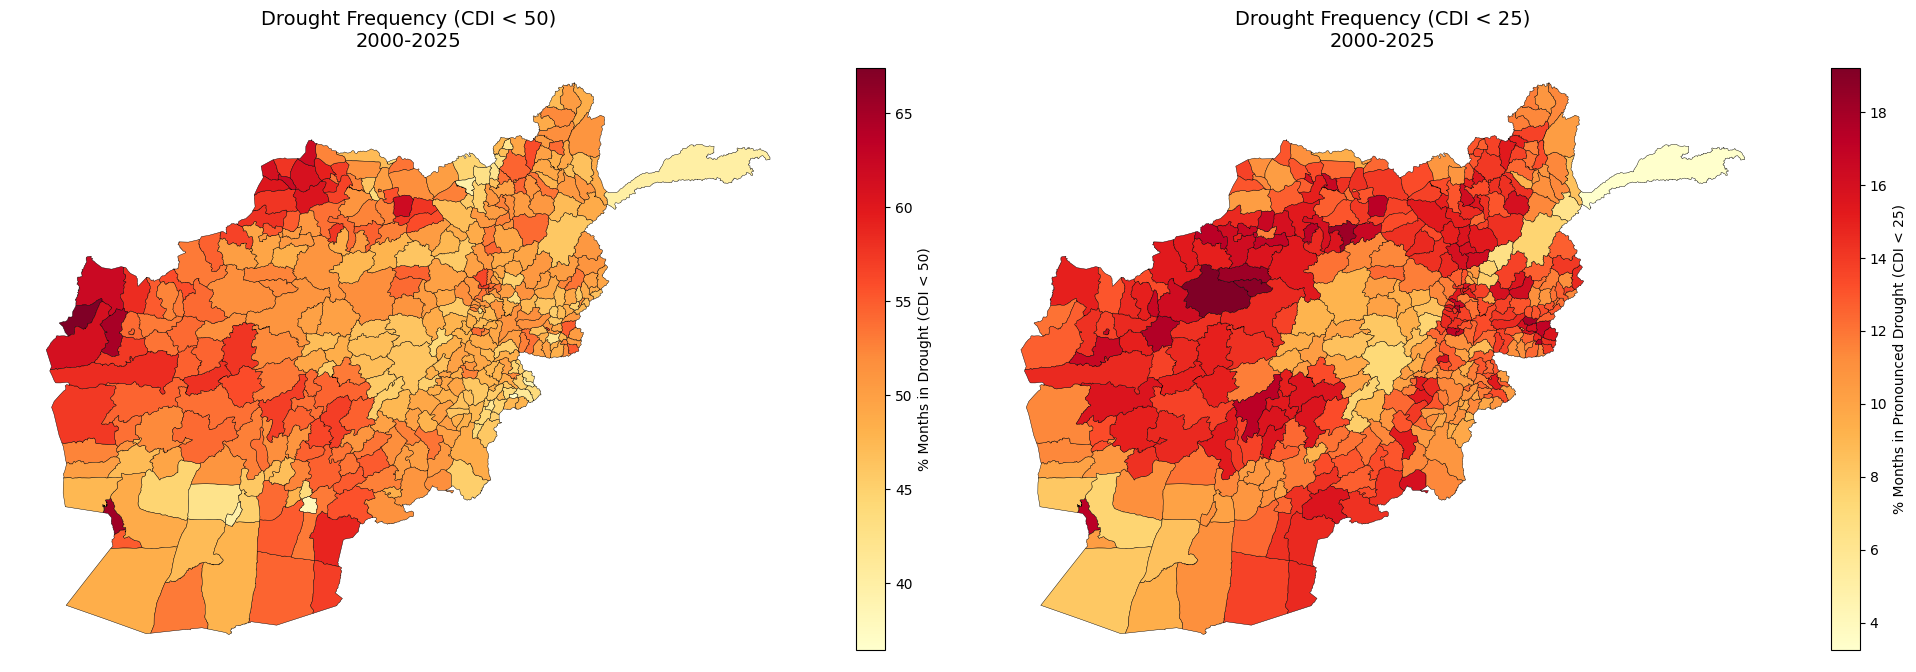

In [101]:
# Drought Hotspot Maps: Moderate vs Severe Drought Frequency 2000-2025

# Calculate % of months in moderate drought (CDI < 50) and severe drought (CDI < 25)
hotspot_freq = df.groupby(["ADM2_CODE", "ADM2_NAME", "ADM1_NAME"]).agg(
    pct_drought_moderate=("CDI", lambda x: (x < 50).sum() / len(x) * 100),
    pct_drought_severe=("CDI", lambda x: (x < 25).sum() / len(x) * 100),
    n_months=("CDI", "count")
).reset_index()

# Merge with district boundaries
hotspot_map = districts_gdf[["ADM2_CODE", "geometry"]].merge(hotspot_freq, on="ADM2_CODE", how="left")

# Left map: Moderate drought (CDI < 50)
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

hotspot_map.plot(
    column="pct_drought_moderate",
    cmap="YlOrRd",
    legend=True,
    legend_kwds={"label": "% Months in Drought (CDI < 50)", "shrink": 0.6},
    edgecolor="black",
    linewidth=0.3,
    missing_kwds={"color": "lightgrey", "label": "No data"},
    ax=axes[0]
)
axes[0].set_title("Drought Frequency (CDI < 50)\n2000-2025", fontsize=14)
axes[0].axis("off")

# Right map: Severe drought (CDI < 25)
hotspot_map.plot(
    column="pct_drought_severe",
    cmap="YlOrRd",
    legend=True,
    legend_kwds={"label": "% Months in Pronounced Drought (CDI < 25)", "shrink": 0.6},
    edgecolor="black",
    linewidth=0.3,
    missing_kwds={"color": "lightgrey", "label": "No data"},
    ax=axes[1]
)
axes[1].set_title("Drought Frequency (CDI < 25)\n2000-2025", fontsize=14)
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [102]:
# Top 10 Least Drought-Prone Districts
print("Top 10 Least Drought-Prone Districts (Highest Mean CDI):\n")
least_drought_prone = df2.nlargest(10, "CDI_mean")[["ADM2_NAME", "ADM1_NAME", "CDI_mean", "CDI_std"]].round(2)
print(least_drought_prone.to_string(index=False))

print("\n")

# Top 10 Most Drought-Prone Districts
print("Top 10 Most Drought-Prone Districts (Lowest Mean CDI):\n")
most_drought_prone = df2.nsmallest(10, "CDI_mean")[["ADM2_NAME", "ADM1_NAME", "CDI_mean", "CDI_std"]].round(2)
print(most_drought_prone.to_string(index=False))

Top 10 Least Drought-Prone Districts (Highest Mean CDI):

       ADM2_NAME  ADM1_NAME  CDI_mean  CDI_std
       Mandozayi      Khost     55.20    22.24
             Bak      Khost     54.74    22.37
        Kandahar   Kandahar     54.35    21.63
          Wakhan Badakhshan     53.69    15.93
        Terezayi      Khost     53.67    22.00
          Sarobi    Paktika     53.56    19.90
      Jajimaydan      Khost     53.54    20.66
    Khost(Matun)      Khost     53.46    21.93
           Ziruk    Paktika     53.44    19.84
Nawa-e-Barakzaiy    Hilmand     53.18    19.71


Top 10 Most Drought-Prone Districts (Lowest Mean CDI):

    ADM2_NAME ADM1_NAME  CDI_mean  CDI_std
         Kang    Nimroz     43.71    19.92
       Kohsan     Hirat     44.44    16.28
       Gulran     Hirat     45.02    17.87
      Khamyab   Jawzjan     45.05    17.68
Feroznakhchir  Samangan     45.08    18.55
     Zindajan     Hirat     45.33    18.34
      Andkhoy    Faryab     45.40    17.78
  Khwajadukoh   Jawzjan

## Seasonality: Monthly CDI by Province

Heatmap showing average CDI by month for each of Afghanistan's 34 provinces. The dry season (November–June) shows CDI below 50 in many provinces, though provincial variation is notable: some experience sharp seasonal drops while others remain relatively stable. This visualization helps identify critical months for drought monitoring by region and supports agricultural planning.

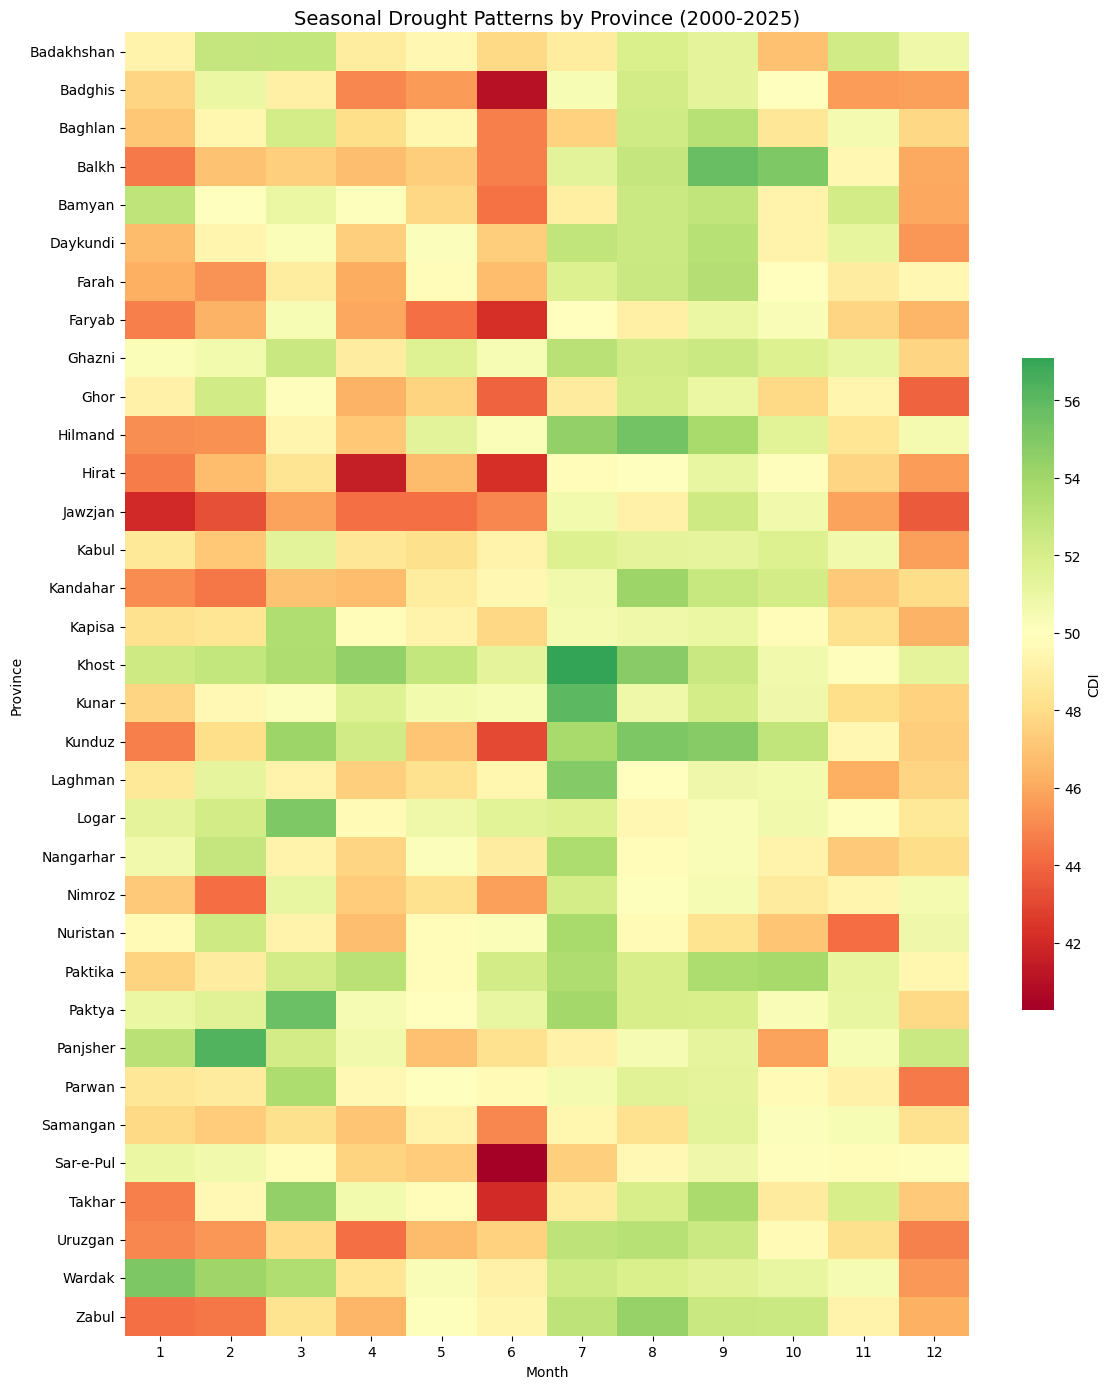

In [103]:
# Monthly CDI averages by province
seasonal = df.groupby(["ADM1_NAME", "month"])["CDI"].mean().unstack()

# Make figure taller to show all 34 provinces
fig, ax = plt.subplots(figsize=(12, 14))
sns.heatmap(seasonal, cmap="RdYlGn", center=50, ax=ax, 
            cbar_kws={"label": "CDI", "shrink": 0.5})
ax.set_title("Seasonal Drought Patterns by Province (2000-2025)", fontsize=14)
ax.set_xlabel("Month")
ax.set_ylabel("Province")
plt.tight_layout()
plt.show()

## CDI Variability Analysis

Map districts by CDI standard deviation to identify areas with the most volatile drought conditions. These districts experience extreme swings between wet and dry conditions, requiring flexible drought preparedness strategies. 

The highest variability was found in Southeastern regions and parts of Western Afghanistan. Notably, Ghazni Province contains 5 of the top 10 most volatile districts.

Top 10 Most Volatile Districts:
  ADM2_NAME ADM1_NAME  CDI_std  CDI_mean
    Kalakan     Kabul    22.92     49.94
    Batikot Nangarhar    22.77     51.45
Barakibarak     Logar    22.66     50.92
    Shinwar Nangarhar    22.53     49.08
Mirbachakot     Kabul    22.51     52.21
       Kama Nangarhar    22.43     50.01
   Kuzkunar Nangarhar    22.43     50.23
        Bak     Khost    22.37     54.74
     Sabari     Khost    22.27     52.39
   Qarabagh     Kabul    22.24     49.32


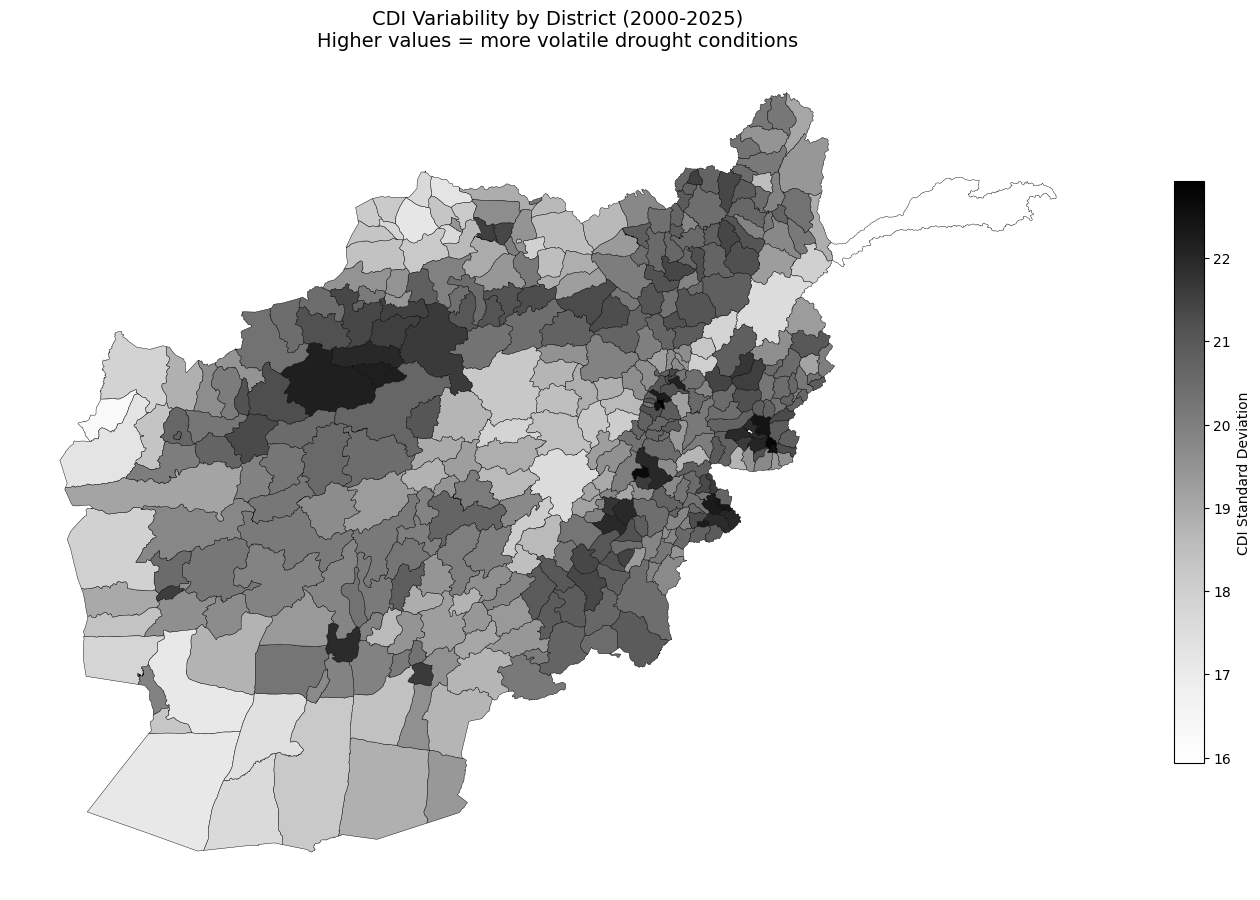

In [104]:
# CDI Variability Map: Most Volatile Districts

# Merge with variability data (CDI_std = standard deviation)
districts_gdf = districts_gdf.merge(
    df2[["ADM2_CODE", "ADM2_NAME", "ADM1_NAME", "CDI_std", "CDI_mean"]], 
    on="ADM2_CODE", 
    how="left"
)

# Create map
fig, ax = plt.subplots(figsize=(14, 10))

districts_gdf.plot(
    column="CDI_std",
    cmap="Greys",
    legend=True,
    legend_kwds={"label": "CDI Standard Deviation", "shrink": 0.6},
    edgecolor="black",
    linewidth=0.3,
    ax=ax
)

ax.set_title("CDI Variability by District (2000-2025)\nHigher values = more volatile drought conditions", fontsize=14)
ax.axis("off")

# Highlight top 10 most volatile districts
top_volatile = df2.nlargest(10, "CDI_std")
print("Top 10 Most Volatile Districts:")
print(top_volatile[["ADM2_NAME", "ADM1_NAME", "CDI_std", "CDI_mean"]].round(2).to_string(index=False))

plt.tight_layout()
plt.show()

## Current Year vs. Historical Average

Compare the most recent year's monthly CDI values against the 2000–2024 historical baseline to identify anomalies.

*Note: December SPI may be missing if data has not yet been updated for the current month.*

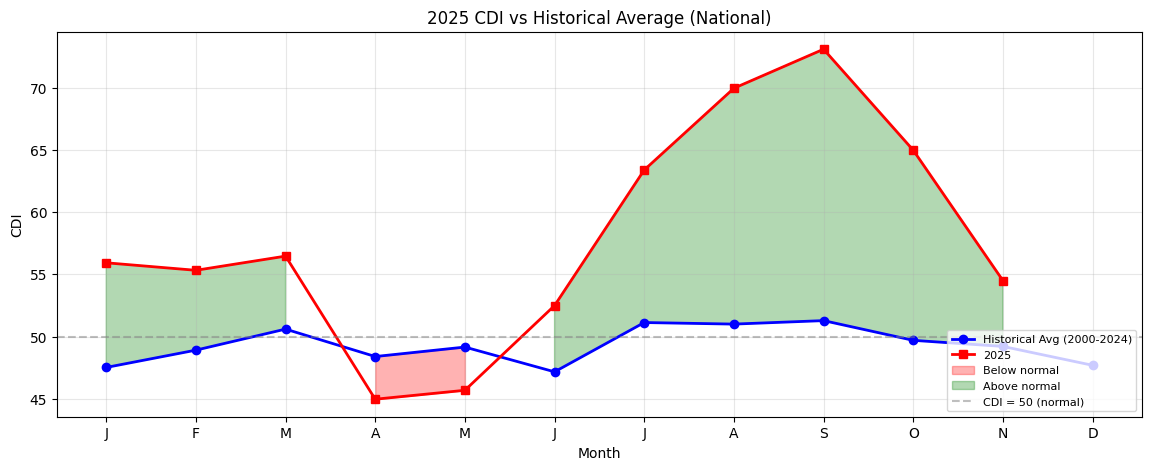

In [105]:
# Anomaly Chart: 2025 vs Historical Average

# Select most recent complete year
current_year = 2025

# Historical average CDI by month (exclude current year)
historical = df[df["year"] < current_year].groupby("month")["CDI"].mean()

# Get current year CDI by month
current = df[df["year"] == current_year].groupby("month")["CDI"].mean()

# Compute anomaly
anomaly = current - historical

# Create chart
fig, ax1 = plt.subplots(figsize=(14, 5))

months = range(1, 13)
ax1.plot(months, historical, 'b-o', linewidth=2, markersize=6, label=f'Historical Avg (2000-{current_year-1})')
ax1.plot(current.index, current.values, 'r-s', linewidth=2, markersize=6, label=f'{current_year}')
ax1.fill_between(months, historical, current.reindex(months), alpha=0.3, 
                  where=current.reindex(months) < historical, color='red', label='Below normal')
ax1.fill_between(months, historical, current.reindex(months), alpha=0.3,
                  where=current.reindex(months) >= historical, color='green', label='Above normal')
ax1.axhline(y=50, color='gray', linestyle='--', alpha=0.5, label='CDI = 50 (normal)')
ax1.set_xlabel("Month")
ax1.set_ylabel("CDI")
ax1.set_title(f"{current_year} CDI vs Historical Average (National)")
ax1.set_xticks(months)
ax1.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
ax1.legend(loc='lower right', fontsize=8)
ax1.grid(True, alpha=0.3)

---
## Summary

This analysis produced district-level drought maps, hotspot identification, and seasonal patterns for Afghanistan from 2000 to 2025. Validation was qualitative: CDI time series and spatial maps were compared against documented drought events and the SPEI Global Drought Monitor. The index captures known droughts but would benefit from quantitative validation against crop yield or food security data.

Future work could optimize CDI weights using ground-truth data or PCA, test sensitivity to different SPI windows (SPI-1, SPI-6, SPI-9, SPI-12), compare clipped vs. unclipped VCI/TCI in the composite, automate data updates via GEE for operational monitoring, and integrate population or livelihood layers for vulnerability analysis.

For interactive exploration, see `dashboard/app.py`. Processed data files are in `data/processed/`.